In [ ]:
#| default_exp embeddings

In [ ]:
#| hide
from fhemb.piece import Piece
from fhemb.embedding import Embedding
from fhemb.utils.factories import pca_factory, wfactory
from nbdev import show_doc

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db


```raw
Embedding
 └── BaseEmbedding
      └── abc.ABC
           └── ValidateSubjsMixin
                └── object
```

# Embedding API

### Embedding-specific methods

In [ ]:
show_doc(Embedding.project, name='project', title_level=4)

---

#### project

```python

def project(
    subjs:List[int]='all', features:NoneType=None, heatmap:NoneType=None, fvector:NoneType=None,
    fbands:List[int]=None, factory:NoneType=None
)->'Embedding':


```

In [ ]:
show_doc(Embedding.create_wdecomposition, name='create_wdecomposition', title_level=4)

---

#### create_wdecomposition

```python

def create_wdecomposition(
    features, # Features to decompose.
    features_int:Tuple[int, ...], # Feature indices to use for decomposition.
    factory:'ConcreteEmbFactory', # Factory that creates the decomposition dictionary.
)->'Wdecomposition': # A wavelet decomposition containing the decomposition dictionary and the projected embedding.


```

*Create a wavelet decomposition for the embedding.*

In [ ]:
show_doc(Embedding.bbootstrap, name='bbootstrap', title_level=4)

---

#### bbootstrap

```python

def bbootstrap(
    subjs:Union[List[int], str]=None, # Subjects to bootstrap.
    err_ts:np.matrix=None, # Error time series.
    block_length:int=None, # in seconds
    max_level:int=8, # Maximum level of the wavelet decomposition.
    rseed:int=None, # Random seed.
)->'Embedding': # Bootstrap resampled embedding.


```

*Perform block bootstrapping on reconstructed signals.*

### Inherited from BaseEmbedding

#### Core utilities


In [ ]:
show_doc(Embedding.calc_shared_bins, name='calc_shared_bins', title_level=4)

---

#### calc_shared_bins

```python

def calc_shared_bins(
    data:np.ndarray[Tint, 'facevector']=None, # Array of heatmaps (frames x features).
    frames:List[int]=None, # Frame indices to include. If None, use all frames.
    method:str='sturges', # Bin edge calculation method passed to `numpy.histogram_bin_edges`.
)->np.ndarray: # Array of bin edges.


```

*Calculate shared bin edges for a set of frames.*

In [ ]:
show_doc(Embedding.clone)

---

### BaseEmbedding.clone

```python

def clone(
    drop_caches:bool=True, # If True, reset internal caches (`_df_ts_subjs`, `_wdecomp`, `_subject_projections`, `_feature2subj2ts`).
    overrides:VAR_KEYWORD
): # A shallow copy of the current instance with caches reset (if requested) and overrides applied.


```

*Create a shallow copy of the embedding.*

In [ ]:
show_doc(Embedding.get_df_ts_subjs, name='get_df_ts_subjs', title_level=4)

---

#### get_df_ts_subjs

```python

def get_df_ts_subjs(
    arg:Union[int, str], # Feature of interest.
)->pd.DataFrame: # DataFrame with subjects as columns and time as index.


```

*Return a DataFrame of time series for subjects for a given feature.*

In [ ]:
show_doc(Embedding.get_feature_idx, name='get_feature_idxs', title_level=4)

---

#### get_feature_idxs

```python

def get_feature_idx(
    ftr:Union[int, str], # Feature of interest, e.g., 'median' or 'pc1'.
)->int: # Index of the feature in `original_features`.


```

*Get the index of a feature in the original feature list.*

In [ ]:
show_doc(Embedding.get_ts_subjs, name='get_ts_subjs', title_level=4)

---

#### get_ts_subjs

```python

def get_ts_subjs(
    args:Union[int, str, list, tuple]=None, # Features of interest (e.g., 'median', 'mean', 'std'). If None, uses the first feature.
)->Union[pd.DataFrame, Dict['feature', pd.DataFrame]]: # DataFrame with subjects as columns (for a single feature) or a dict mapping feature -> DataFrame.


```

*Return time series data for subjects.*

### Plotting / visualization helpers

In [ ]:
show_doc(Embedding.plot_signal, name='plot_signal', title_level=4)

---

#### plot_signal

```python

def plot_signal(
    subjs:List[str], # Subjects to plot.
    feature:int=None, # Feature index to plot. If None and multiple features exist, an error is raised.
    title:str='', # Title suffix for the plot.
    label:str='', # Label for the plot.
    linestyle:str='-', # Line style.
    show:bool=True, # Whether to call `plt.show()`.
): # (fig, axes) of the created matplotlib figure.


```

*Plot the signals for given subjects.*

In [ ]:
show_doc(Embedding.plot_temperaturebars, name='plot_temperaturebars', title_level=4)

---

#### plot_temperaturebars

```python

def plot_temperaturebars(
    subjs:List[int]='all', # Subjects to plot.
    frms:List[int]=None, # Frames to display.
    sharex:bool=True, # Share x-axis between plots.
    sharey:bool=True, # Share y-axis between plots.
    centralized:bool=False, # Whether to centralize the values around the mean.
    kwargs:VAR_KEYWORD
):


```

*Plot temperature bar charts for selected subjects and frames.*

In [ ]:
show_doc(Embedding.plot_temperaturehist, name='plot_temperaturehist', title_level=4)

---

#### plot_temperaturehist

```python

def plot_temperaturehist(
    subjs:List[int]='all', # Subjects to plot.
    frms:List[int]=None, # Frames to include.
    sharex:bool=True, # Share x-axis between plots.
    sharey:bool=True, # Share y-axis between plots.
    kwargs:VAR_KEYWORD
):


```

*Plot heatmap histograms for subjects and specified frames.*

In [ ]:
show_doc(Embedding.plot_intvlhist, name='plot_intvlhist', title_level=4)

---

#### plot_intvlhist

```python

def plot_intvlhist(
    subjs, # Subjects to plot.
    intvl:tuple=(0, 10), # Time interval (start, end) in frames.
    sharex:bool=True, # Share x-axis between plots.
    sharey:bool=True, # Share y-axis between plots.
    feature:NoneType=None, # Feature to plot.
    kwargs:VAR_KEYWORD
):


```

*Plot histograms of temperature bins for a given interval.*

In [ ]:
show_doc(Embedding.visualize_eigenfaces, name='visualize_eigenfaces', title_level=4)

---

#### visualize_eigenfaces

```python

def visualize_eigenfaces(
    subjs:NoneType=None, # Subjects to visualize. If None, uses all available subjects.
    components:list=[0], # Eigenface indices to display.
    cmap:str='hot', # *args, subjs='all',**kwargs
returns func(subjs, *args, **kwargs)
    kwargs:VAR_KEYWORD
): # Mapping from subject to list of figures.


```

*Visualize eigenfaces for a list of subjects.*

### Static plotting helpers

In [ ]:
show_doc(Embedding.create_subplots, name='create_subplots', title_level=4)

---

#### create_subplots

```python

def create_subplots(
    nrows, # Number of rows.
    ncols, # Number of columns.
    scale:int=4, # Scale factor for figure size.
    sharex:bool=True, # Whether to share x-axis across subplots.
    sharey:bool=True, # Whether to share y-axis across subplots.
    extra_height:int=0, # Additional height to add to the figure.
): # (fig, axs) where axs is a 2D array of axes.


```

*Create a figure and axes grid with consistent scaling.*

In [ ]:
show_doc(Embedding.plot_bar, name='plot_bars', title_level=4)

---

#### plot_bars

```python

def plot_bar(
    ax, # Axis to plot on.
    x, # X positions for the bars.
    height, # Heights of the bars.
    width, # Widths of the bars.
    title:NoneType=None, # Title for the plot.
):


```

*Plot a bar chart on a given matplotlib axis.*

In [ ]:
show_doc(Embedding.plot_histogram, name='plot_histogram', title_level=4)

---

#### plot_histogram

```python

def plot_histogram(
    ax, # Axis to plot on.
    data, # Data values to histogram.
    bins, # Bin edges.
    title:NoneType=None, # Title for the plot.
): # Histogram bin counts.


```

*Plot a histogram on a given matplotlib axis.*

### Other useful bits

```Python
sr = 25 (sampling rate)
```

### Validation helper from ValidateSubjsMixin

In [ ]:
show_doc(Embedding.get_subjects, title_level=4)

---

#### ValidateSubjsMixin.get_subjects

```python

def get_subjects(
    subjs:Union, sort:bool=True
)->list:


```

*Check the `subjects` and normalize it:*
- if 'all', take all subjects
- if empty, raise an error
- if not a list of integers raise an error
    - check if the corresponding list of strings in the range of subjects
        - if not, raise an error

In [ ]:
#| export

dg0 = Piece(title='Don Giovanni', time_interval=(14200,15200), subjs=[(65,68)])

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(65, 68)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[65, 66, 67, 68] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [65, 66, 67, 68]
 [DEBUG] piece.__init__: Compact numeric subjects: [(65, 68)]


 [INFO] piece._load_from_db: Loading face_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj65, subj66, subj67, subj68 FROM dg.faceposition_t WHERE frame_number >= 14200 AND frame_number < 15200 ORDER BY frame_number
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/paramiko/transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,
 [DEBUG] piece.start: SSH tunnel established
 [DEBUG] piece.start: Effective DB params

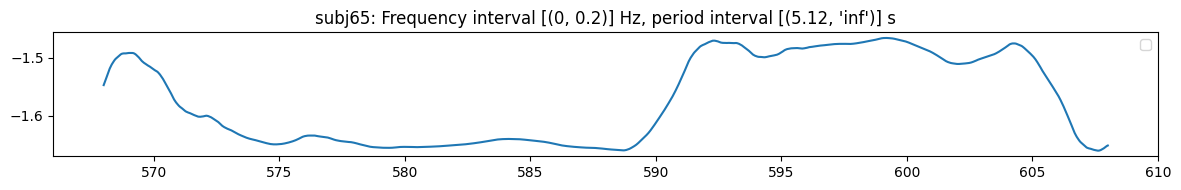

(<Figure size 1200x200 with 1 Axes>,
 [<Axes: title={'center': "subj65: Frequency interval [(0, 0.2)] Hz, period interval [(5.12, 'inf')] s"}>])

In [ ]:
#| eval: false

dg0.face_t.project(features=['skew'], subjs=[65], fbands=[0,1,2], wdfactory=wfactory('db4',8)).plot_signal(subjs=[65])

In [ ]:
#| eval: false

dg0.facebbox_t.plot_pdf(subj=65, secs=[568, 576], bw_method=0.1)

 [INFO] piece._load_from_db: Loading facebbox_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj65, subj66, subj67, subj68 FROM dg.faceposition_t WHERE frame_number >= 14200 AND frame_number < 15200 ORDER BY frame_number
 [DEBUG] piece.start: SSH tunnel established
 [DEBUG] piece.start: Effective DB params after start: dbname=tcamera user=tanalyst host=127.0.0.1 port=59557
 [DEBUG] dbms.__enter__: Database connection opened: True (conn.closed=0)
 [DEBUG] dbms.__enter__: Database cursor opened: True
 [INFO] dbms.data_query: Fetching time series of ['subj65', 'subj66', 'subj67', 'subj68']
 [DEBUG] dbms.__exit__: __exit__ called with exc_type=None, 
exc_val=None, 
exc_tb=None
 [DEBUG] dbms.__exit__: Cursor closed: True
 [DEBUG] dbms.__exit__: Transaction committed
 [DEBUG] dbms.__exit__: Connection closed: True (conn.closed = 1)
 [INFO] piece.fetch_timeseries: 1000 rows fetched successfully!
 [DEBUG] piece.stop: SSH tunnel closed
 [INFO] piece._fetch_from